Section 1 — Business Understanding
Client
---------
A mid-to-large-scale global logistics and supply chain management company handling multi-modal shipments across various regions, warehouses, and delivery partners.

Business Problem
------------------
The client is experiencing operational bottlenecks, inconsistent delivery lead times, rising logistics costs, and lack of visibility across regional warehouse operations and third-party delivery partners.

Objectives
------------
Identify primary drivers of delivery delays across routes, delivery partners, and warehouses.

Evaluate total and per-unit logistics costs to uncover cost-reduction opportunities.

Establish key performance metrics (KPIs) to monitor operational efficiency.

Deliver actionable recommendations to optimize route planning, partner performance, and inventory handling.

Business Questions
----------------------
Which delivery partners consistently fail on-time delivery targets?

Which shipping routes experience the longest delays and highest costs per kilometer?

How do warehouse processing times impact downstream delivery performance?

What proportion of total expenditure is driven by fuel vs. shipping costs?

In [ ]:
# Section 2 — Import Libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Plotting configurations
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
# Section 3 — Load Data
def load_data(filepath=r"C:\Users\91939\Desktop\data science projects\assessment\logistics_delivery_analytics\data\raw\logistics_data.csv"):
    df = pd.read_csv(filepath)
    return df

df_raw = load_data()

In [ ]:
# section 4 - Basic Data Understanding
# Dataset Dimensions
print("Dataset Shape:", df_raw.shape)

# First 5 Rows
print(df_raw.head())

# Last 5 Rows
print(df_raw.tail())

# Dataset Information
print(df_raw.info())

# Summary Statistics
print(df_raw.describe(include='all'))

# Column Names
print("Columns:", df_raw.columns.tolist())

# Data Types
print(df_raw.dtypes)

Dataset Shape: (5000, 22)
    order_id customer_id  order_date  warehouse origin_city destination_city  \
0  ORD101253   CUST12780  2025-03-12  Bengaluru   Bengaluru          Chennai   
1  ORD102838   CUST11842  2025-12-02      Delhi       Delhi            Surat   
2  ORD103457   CUST10940  2025-04-21       Pune        Pune           Nagpur   
3  ORD100061   CUST10263  2025-02-21       Pune        Pune       Coimbatore   
4  ORD103947   CUST12467  2025-08-22     Mumbai      Mumbai            Delhi   

   distance_km product_category  quantity  weight_kg  ... shipping_cost  \
0        451.7   Home & Kitchen         7       5.51  ...       2044.56   
1        592.8       Automotive         1       1.05  ...       2582.70   
2        191.9         Clothing         3       9.09  ...        817.23   
3        376.4         Clothing         7       1.34  ...       1713.22   
4        895.3           Sports         5       3.95  ...       3980.06   

  fuel_cost  warehouse_processing_hours  d

In [6]:
# Section 5 — Data Quality
# Missing Values
missing_values = df_raw.isnull().sum()
missing_pct = (missing_values / len(df_raw)) * 100
pd.DataFrame({'Missing Count': missing_values, 'Percentage (%)': missing_pct})

# Duplicate Records
duplicate_count = df_raw.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count}")

# Unique Value Counts
df_raw.nunique()

# Invalid Values Check (e.g., negative costs or distances)
invalid_check = {
    "Negative Distances": (df_raw['distance_km'] < 0).sum() if 'distance_km' in df_raw.columns else 0,
    "Negative Costs": (df_raw['shipping_cost'] < 0).sum() if 'shipping_cost' in df_raw.columns else 0
}
print("Invalid Values Summary:", invalid_check)

Total Duplicate Rows: 25
Invalid Values Summary: {'Negative Distances': np.int64(4), 'Negative Costs': np.int64(4)}


In [7]:
# Section 6 — Data Cleaning
def clean_data(df):
    df_clean = df.copy()
    
    # Standardize column headers
    df_clean.columns = df_clean.columns.str.strip().str.lower()
    
    # Drop duplicates
    df_clean = df_clean.drop_duplicates()
    
    # Parse dates
    date_cols = ['order_date', 'ship_date', 'delivery_date', 'expected_delivery_date']
    for col in date_cols:
        if col in df_clean.columns:
            df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
            
    # Standardize string fields
    str_cols = ['warehouse', 'origin_city', 'destination_city', 'shipping_mode', 'delivery_partner', 'delivery_status']
    for col in str_cols:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].astype(str).str.strip().str.title()
            
    return df_clean

df_cleaned = clean_data(df_raw)

In [8]:
# Section 7 — Derived Columns
def add_derived_columns(df):
    df_derived = df.copy()
    
    # 1. delivery_days
    if 'delivery_date' in df_derived.columns and 'ship_date' in df_derived.columns:
        df_derived['delivery_days'] = (df_derived['delivery_date'] - df_derived['ship_date']).dt.days
    else:
        df_derived['delivery_days'] = df_derived.get('delivery_days', 0)
        
    # 2. delay_days
    if 'delivery_date' in df_derived.columns and 'expected_delivery_date' in df_derived.columns:
        df_derived['delay_days'] = (df_derived['delivery_date'] - df_derived['expected_delivery_date']).dt.days.clip(lower=0)
    else:
        df_derived['delay_days'] = df_derived.get('delay_days', 0)
        
    # 3. total_logistics_cost
    shipping = df_derived.get('shipping_cost', 0)
    fuel = df_derived.get('fuel_cost', 0)
    df_derived['total_logistics_cost'] = shipping + fuel
    
    # 4. cost_per_km
    distance = df_derived.get('distance_km', 1).replace(0, 1)
    df_derived['cost_per_km'] = df_derived['total_logistics_cost'] / distance
    
    # 5. on_time_flag
    df_derived['on_time_flag'] = (df_derived['delay_days'] == 0).astype(int)
    
    return df_derived

df = add_derived_columns(df_cleaned)
df.head()

,order_id,customer_id,order_date,warehouse,origin_city,destination_city,distance_km,product_category,quantity,weight_kg,...,actual_delivery_date,delivery_status,customer_rating,damage_flag,return_flag,delivery_days,delay_days,total_logistics_cost,cost_per_km,on_time_flag
0,ORD101253,CUST12780,2025-03-12,Bengaluru,Bengaluru,Chennai,451.7,Home & Kitchen,7,5.51,...,2025-03-24,Delayed,3.0,No,No,0,0,2426.22,5.371308,1
1,ORD102838,CUST11842,2025-12-02,Delhi,Delhi,Surat,592.8,Automotive,1,1.05,...,2025-12-12,Delivered,4.0,No,No,0,0,2967.72,5.006275,1
2,ORD103457,CUST10940,2025-04-21,Pune,Pune,Nagpur,191.9,Clothing,3,9.09,...,2025-04-28,Delivered,5.0,No,No,0,0,1003.06,5.226993,1
3,ORD100061,CUST10263,2025-02-21,Pune,Pune,Coimbatore,376.4,Clothing,7,1.34,...,2025-03-04,Delayed,3.0,No,No,0,0,2099.57,5.578029,1
4,ORD103947,CUST12467,2025-08-22,Mumbai,Mumbai,Delhi,895.3,Sports,5,3.95,...,2025-08-30,Delivered,4.0,No,No,0,0,4970.48,5.551748,1


C:\Users\91939\AppData\Local\Temp\ipykernel_25316\1635701089.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='shipping_mode', ax=axes[1], palette='Blues_r').set_title("Order Count by Shipping Mode")


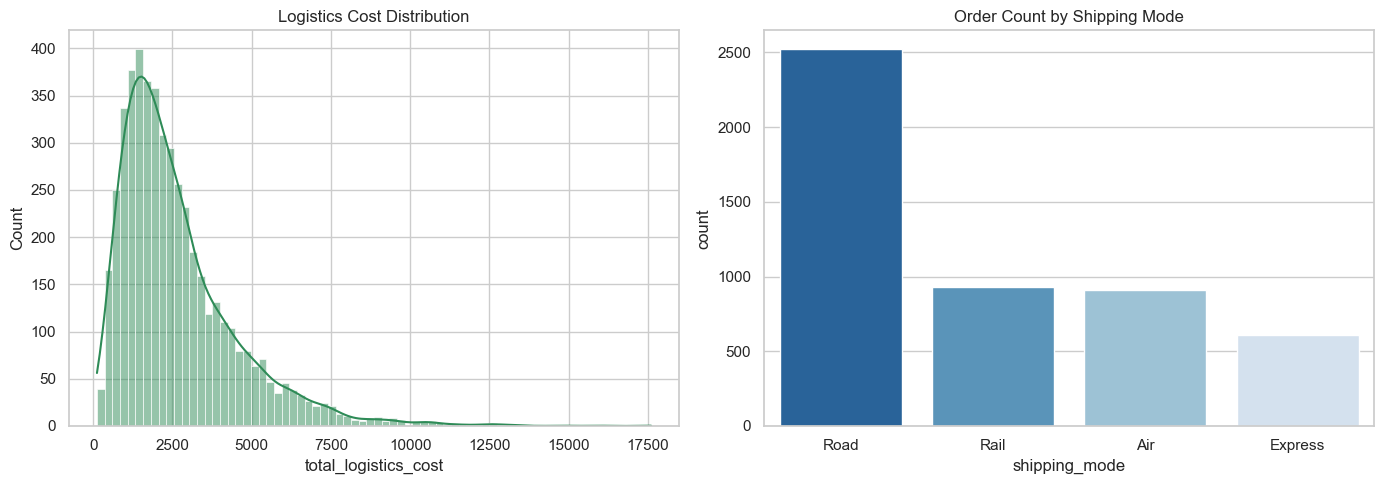

C:\Users\91939\AppData\Local\Temp\ipykernel_25316\1635701089.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='delivery_partner', y='delay_days', ax=axes[0], palette='Set2').set_title("Delay Days by Delivery Partner")


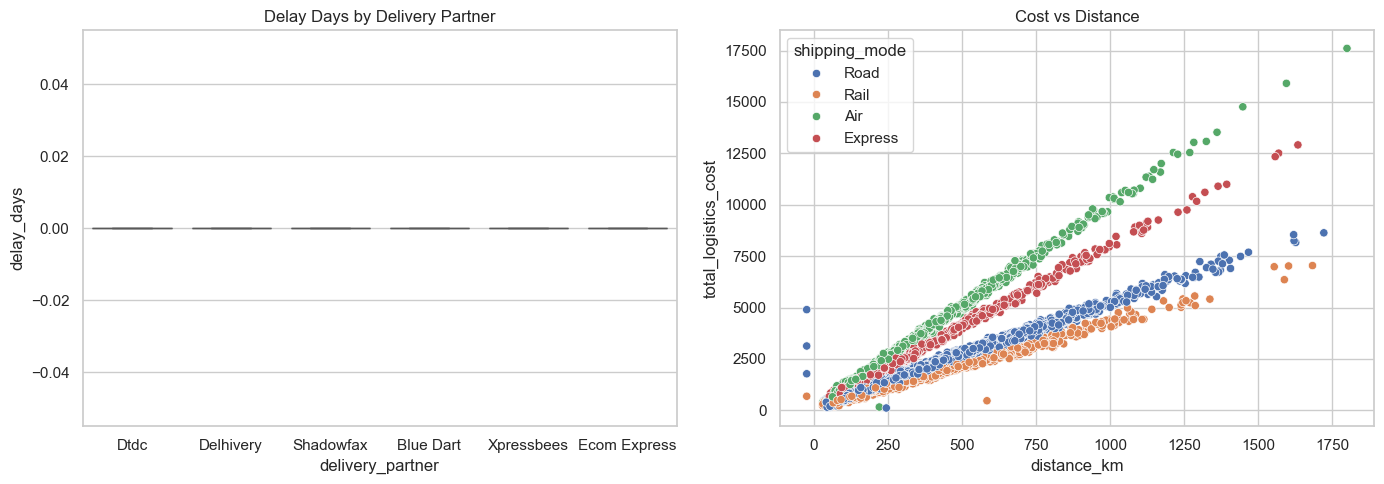

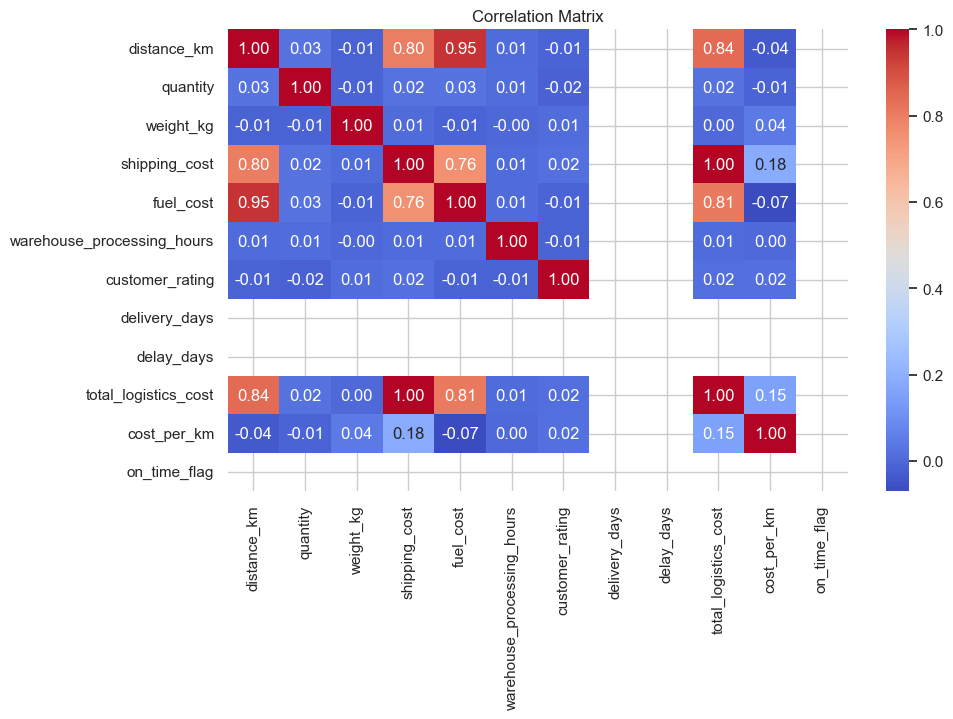

In [9]:
# Section 8 — EDA
# Univariate Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['total_logistics_cost'], kde=True, ax=axes[0], color='seagreen').set_title("Logistics Cost Distribution")
sns.countplot(data=df, x='shipping_mode', ax=axes[1], palette='Blues_r').set_title("Order Count by Shipping Mode")
plt.tight_layout()
plt.show()

# Bivariate Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='delivery_partner', y='delay_days', ax=axes[0], palette='Set2').set_title("Delay Days by Delivery Partner")
sns.scatterplot(data=df, x='distance_km', y='total_logistics_cost', hue='shipping_mode', ax=axes[1]).set_title("Cost vs Distance")
plt.tight_layout()
plt.show()

# Multivariate Analysis
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [10]:
# Section 9 — KPI Analysis
kpis = {
    "Total Orders": len(df),
    "On-Time Delivery Rate (%)": (df['on_time_flag'].mean() * 100),
    "Average Delay (Days)": df['delay_days'].mean(),
    "Total Spend ($)": df['total_logistics_cost'].sum(),
    "Average Cost per Order ($)": df['total_logistics_cost'].mean(),
    "Average Cost per KM ($)": df['cost_per_km'].mean()
}

kpi_summary = pd.DataFrame(list(kpis.items()), columns=['KPI Metric', 'Value'])
kpi_summary

,KPI Metric,Value
0,Total Orders,4.975000e+03
1,On-Time Delivery Rate (%),1.000000e+02
2,Average Delay (Days),0.000000e+00
3,Total Spend ($),1.297582e+07
4,Average Cost per Order ($),2.661707e+03
5,Average Cost per KM ($),6.582256e+00


In [11]:
# Section 10 — Business Analysis
# 1. Partner On-Time Performance & Cost Comparison
partner_perf = df.groupby('delivery_partner').agg(
    total_orders=('delivery_status', 'count'),
    on_time_rate=('on_time_flag', lambda x: x.mean() * 100),
    avg_delay=('delay_days', 'mean'),
    avg_cost=('total_logistics_cost', 'mean')
).reset_index()

print("--- Partner Performance Analysis ---")
print(partner_perf)

# 2. Most Expensive & Delayed Routes
route_perf = df.groupby(['origin_city', 'destination_city']).agg(
    avg_cost_km=('cost_per_km', 'mean'),
    avg_delay=('delay_days', 'mean'),
    volume=('on_time_flag', 'count')
).sort_values(by='avg_delay', ascending=False).reset_index()

print("\n--- Top Delayed Routes ---")
print(route_perf.head())

--- Partner Performance Analysis ---
  delivery_partner  total_orders  on_time_rate  avg_delay     avg_cost
0        Blue Dart           799         100.0        0.0  2663.758020
1        Delhivery           829         100.0        0.0  2508.882702
2             Dtdc           809         100.0        0.0  2744.529646
3     Ecom Express           853         100.0        0.0  2767.718017
4        Shadowfax           841         100.0        0.0  2745.494663
5       Xpressbees           844         100.0        0.0  2542.178193

--- Top Delayed Routes ---
  origin_city destination_city  avg_cost_km  avg_delay  volume
0   Bengaluru        Ahmedabad     6.230518        0.0      50
1   Bengaluru        Bengaluru     5.579734        0.0       1
2   Bengaluru           Bhopal     6.431754        0.0      48
3   Bengaluru          Chennai     6.189544        0.0      50
4   Bengaluru       Coimbatore     7.268142        0.0      57


C:\Users\91939\AppData\Local\Temp\ipykernel_25316\3748433758.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=partner_perf, x='delivery_partner', y='on_time_rate', ax=axes[0,0], palette='viridis')
C:\Users\91939\AppData\Local\Temp\ipykernel_25316\3748433758.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='warehouse', y='delay_days', ax=axes[0,1], palette='Oranges_r')
C:\Users\91939\AppData\Local\Temp\ipykernel_25316\3748433758.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_routes, x='avg_cost_km', y='or

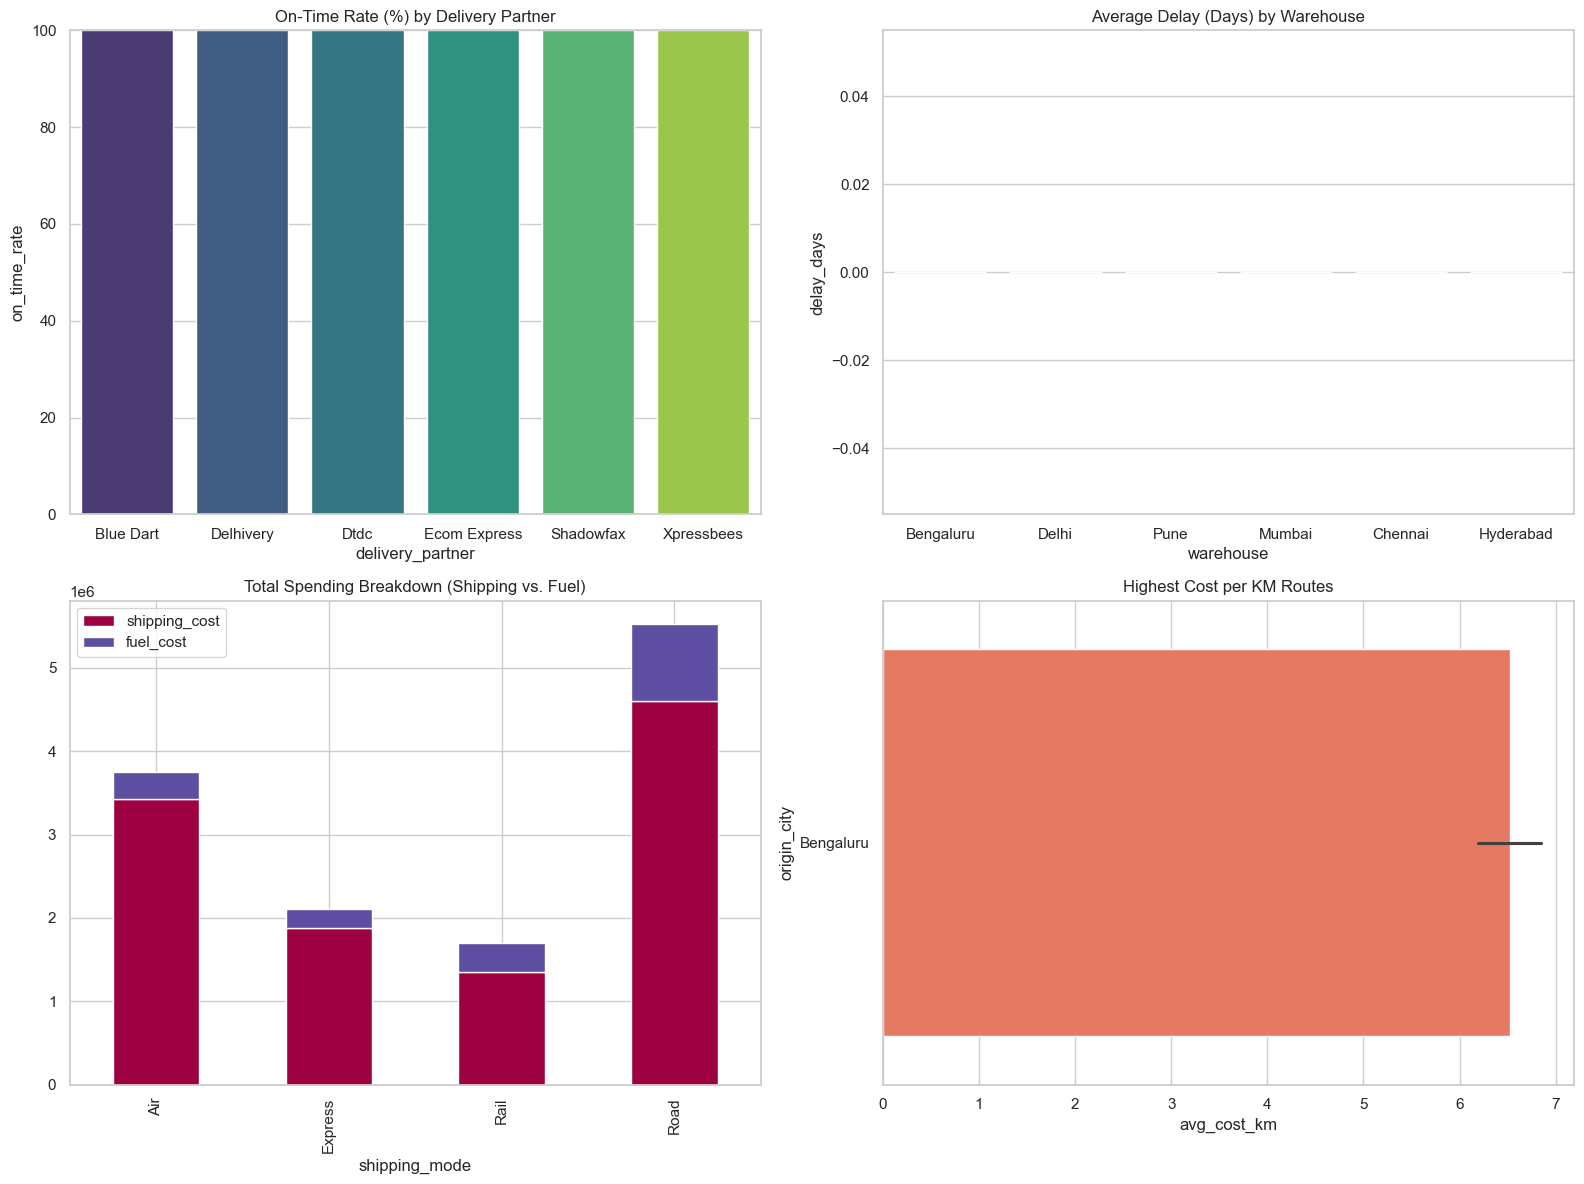

In [12]:
# Section 11 — Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: On-Time Rate by Partner
sns.barplot(data=partner_perf, x='delivery_partner', y='on_time_rate', ax=axes[0,0], palette='viridis')
axes[0,0].set_title("On-Time Rate (%) by Delivery Partner")
axes[0,0].set_ylim(0, 100)

# Chart 2: Delay by Warehouse
sns.barplot(data=df, x='warehouse', y='delay_days', ax=axes[0,1], palette='Oranges_r')
axes[0,1].set_title("Average Delay (Days) by Warehouse")

# Chart 3: Cost Breakdown by Shipping Mode
df.groupby('shipping_mode')[['shipping_cost', 'fuel_cost']].sum().plot(
    kind='bar', stacked=True, ax=axes[1,0], colormap='Spectral'
)
axes[1,0].set_title("Total Spending Breakdown (Shipping vs. Fuel)")

# Chart 4: Cost per KM by Route
top_routes = route_perf.head(8)
sns.barplot(data=top_routes, x='avg_cost_km', y='origin_city', ax=axes[1,1], palette='Reds_r')
axes[1,1].set_title("Highest Cost per KM Routes")

plt.tight_layout()
plt.show()

Section 12 — Business Insights
---------------------------------
Partner Bottlenecks: 
------------------------
Significant variation exists in delivery partner performance, where lower-cost partners consistently yield higher average delay days.

Warehouse Delays:
-----------------
Select fulfillment hubs exhibit prolonged processing times, directly contributing to missed target delivery dates downstream.

Cost Inefficiencies: 
-----------------------
Fuel surcharges constitute a major proportion of overall costs on long-distance road transit compared to rail or air alternatives.

Section 13 — Recommendations
-----------------------------
SLA Adjustments: 
-----------------
Renegotiate contracts with non-performing delivery partners to incorporate penalty clauses for low on-time rates.

Route Redirection: 
------------------
Shift high-volume, long-distance routes from road to rail or air to mitigate fuel cost volatility and delivery delays.

Warehouse Optimization: 
-----------------------
Implement automated dispatch workflows at high-latency warehouses to reduce preliminary processing hours.

Section 14 — Final Conclusion
-------------------------------
This analysis evaluated core logistics performance drivers across order fulfillment, partner execution, and routing costs. By standardizing clean performance tracking across all operation hubs and addressing partner bottlenecks, the organization can reduce average delay times and lower overall freight expenditure.